In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import TotalVariationRecon, L1WaveletRecon
from scipy.io import savemat, loadmat
import twixtools
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.signal import butter,filtfilt


## My files
from ksp_plot_helpers import plot_ksp_data_multichannel, find_and_plot_acquired_region
from raw_data_utils import get_kspace_data, get_TR
from resp_signal_functions import resp_signal_all_slices, resp_signal_single_slice, resp_signal_center_sample_single_slice
from resp_signal_plot_functions import *
import gating_functions
from pca_helper import pca_resp_signal
import save_data_helpers

In [4]:
import numpy as np
import os

# Base directory
base_dir = "/home/lilianae/projects/naf_clean/admm_results/mini_admm_z_base_rho_0.01_beta_0.0001_15iters/iters"

# Iteration to unpack
iter_num = 14
npz_path = os.path.join(base_dir, f"iter_{iter_num:03d}.npz")

# Load npz file
data = np.load(npz_path)

def reshape_mvf(mvf_flat, mvf_shape, num_gates):
    mvf = np.reshape(mvf_flat, (*mvf_shape, 3, num_gates), order='F')
    mvf = np.moveaxis(mvf, -1, 0)
    return mvf

# Inspect available arrays
print("Available arrays in npz:", data.files)

# Unpack
num_gates = 5
img_shape = (58, 512, 512) 
mvf_shape = (58, 512, 512) 
S_inv = reshape_mvf(data["S_inv"], mvf_shape, num_gates)      # shape: (num_gates, z, y, x, 3)
S = reshape_mvf(data["S"], mvf_shape, num_gates)
z_abs = np.abs(data["z"])      # shape: (num_gates, x, y, z)

print(f"S_inv.shape = {S_inv.shape}")
print(f'S.shape = {S.shape}')
print(f"z_abs.shape = {z_abs.shape}")


Available arrays in npz: ['z', 'lam', 'u', 'S', 'S_inv']
S_inv.shape = (5, 58, 512, 512, 3)
S.shape = (5, 58, 512, 512, 3)
z_abs.shape = (5, 58, 512, 512)


len(gated_recons) = 5
gated_recons shape: (58, 256, 256)
(58, 256, 2)
Saved II with shape: (58, 256, 2)


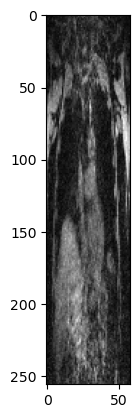

In [3]:
import pickle
import numpy as np
from scipy.io import savemat

gated_recons = save_data_helpers.read_pickle('gated_cropped_recons_NUFFT_phil5gates.pkl')
print(f'len(gated_recons) = {len(gated_recons)}')
print(f"gated_recons shape: {gated_recons[0].shape}")  # Should be (5, 58, 512, 512)

def extract_center_slice(img, slice_axis, slice_idx=None):
    Nz, Ny, Nx = img.shape
    
    if slice_idx is None:
        slice_idx = img.shape[slice_axis] // 2

    if slice_axis==0:
        center_slice = img[slice_idx, :, :]
    elif slice_axis==1:
        center_slice = img[:, slice_idx, :]
    elif slice_axis==2:
        center_slice = img[:, :, slice_idx]

    return center_slice


gate_2_all_slices = []
gate_3_all_slices = []

for slice_axis in range(3):
    gate_2_img = extract_center_slice(gated_recons[2], slice_axis=slice_axis)
    gate_3_img = extract_center_slice(gated_recons[3], slice_axis=slice_axis)
    # plt.figure()
    # plt.imshow(np.abs(gate_2_img), cmap='gray')
    # plt.show()
    gate_2_all_slices.append(gate_2_img)
    gate_3_all_slices.append(gate_3_img)

plt.imshow(np.rot90(np.abs(gate_2_all_slices[2]), k=-1), cmap='gray')
# Stack as time sequence for optical flow
II = np.stack([gate_2_all_slices[2], gate_3_all_slices[2]], axis=2)  # Shape: (58, 512, 2)
print(II.shape)

# Save to .mat file
savemat('gate2_gate3_frames.mat', {'II': II})
print(f"Saved II with shape: {II.shape}")